# **实验二：传统机器学习**

1. **监督学习——鸢尾花分类**
   - **分类器**：对数回归、决策树、支持向量机。
   - **性能分析**：准确率、F1 分数、混淆矩阵、ROC 曲线等指标；并分析正则化强度、树深度、核函数等超参数的影响。
2. **无监督学习——客户细分**
   - 使用 PCA / t-SNE 降维。
   - 采用 KMeans、层次聚类、DBSCAN 进行客户群体划分。
   - 通过轮廓系数等内部指标评估聚类效果。

In [75]:
%cd /content/Drive/MyDrive/Colab/AiLab/Lab2

/content/Drive/MyDrive/Colab/AiLab/Lab2


# **0 导入环境**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

from Sources.Supervised import (
    LoadIris, CheckMissing, SplitAndScale,
    PlotBoxPlots, PlotPairPlot, PlotCorrelationHeatmap, PlotParallelCoordinates,
    PlotConfusionMatrices, PlotPerformanceComparison,
    PlotDecisionBoundary, PlotROCCurves
)
from Sources.Unsupervised import (
    LoadMallCustomers, PreprocessMall, ReducePCA, ReduceTSNE,
    PlotDistributions, PlotGenderDistribution, PlotIncomeVsSpending, PlotBoxPlots as PlotMallBox,
    PlotPCAVariance, PlotDimComparison, EvaluateKMeans,
    RunClustering, PlotClusteringComparison,
    PlotClusterCenters, PlotRadarChart, PlotFeatureDistributionByCluster, PlotKComparison
)

## **0.1 参数**

In [36]:
UNSUPERVISED_DATASET = "./Datasets/Mall_Customers.csv"

# **1 监督学习——鸢尾花分类**

## **1.1 加载数据**

In [76]:
iris, df_iris = LoadIris()

Shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples per class:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
5,5.4,3.9,1.7,0.4,setosa,0
6,4.6,3.4,1.4,0.3,setosa,0
7,5.0,3.4,1.5,0.2,setosa,0
8,4.4,2.9,1.4,0.2,setosa,0
9,4.9,3.1,1.5,0.1,setosa,0


In [77]:
CheckMissing(df_iris)

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
target               0
dtype: int64

Total missing: 0


In [78]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## **1.2 数据可视化**

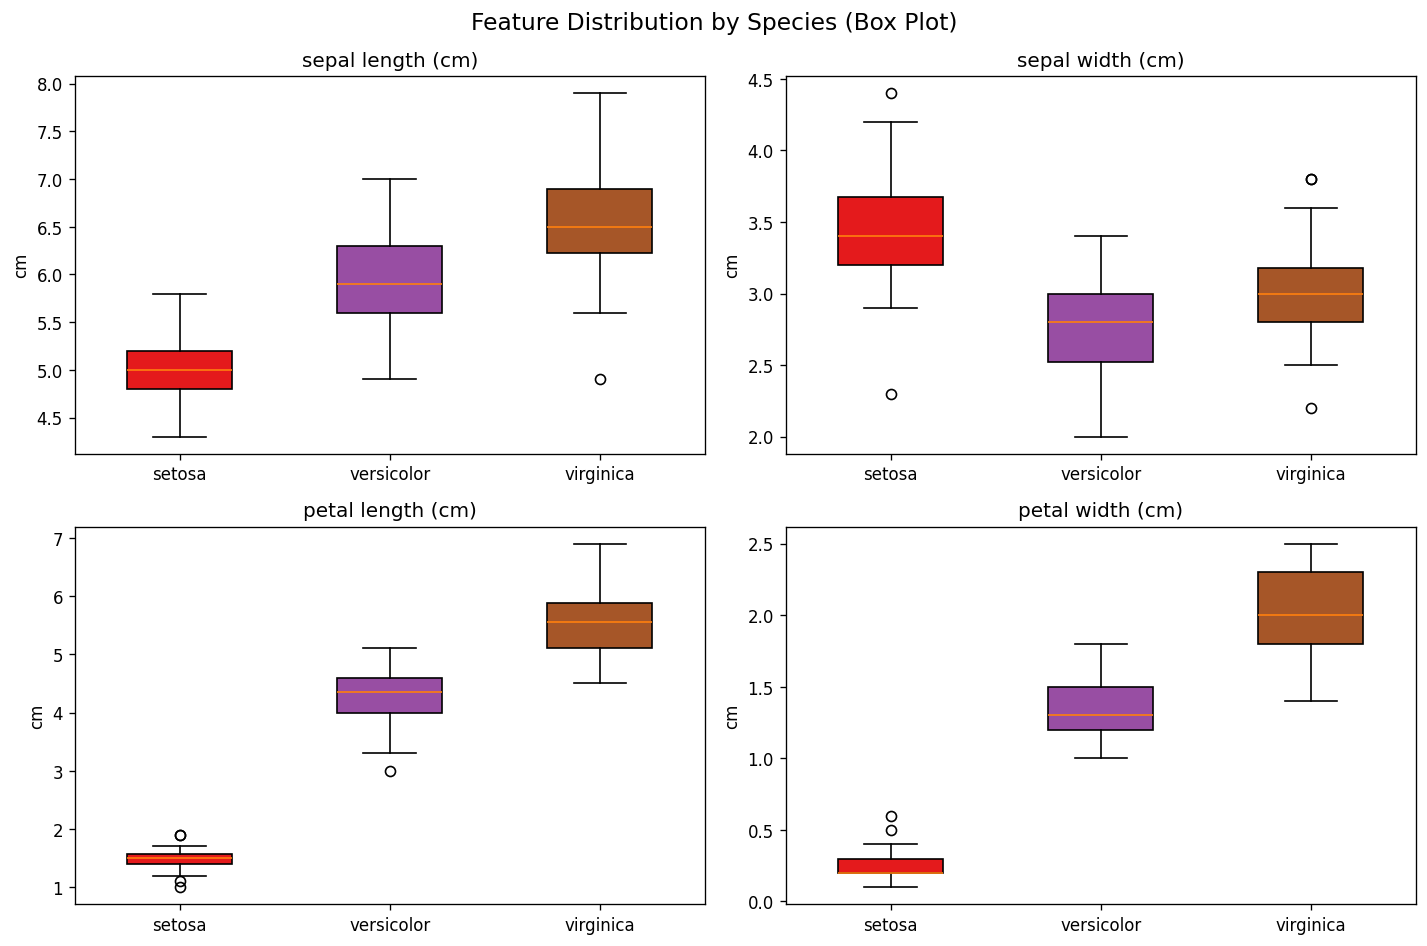

In [38]:
PlotBoxPlots(df_iris, iris.feature_names, iris.target_names)

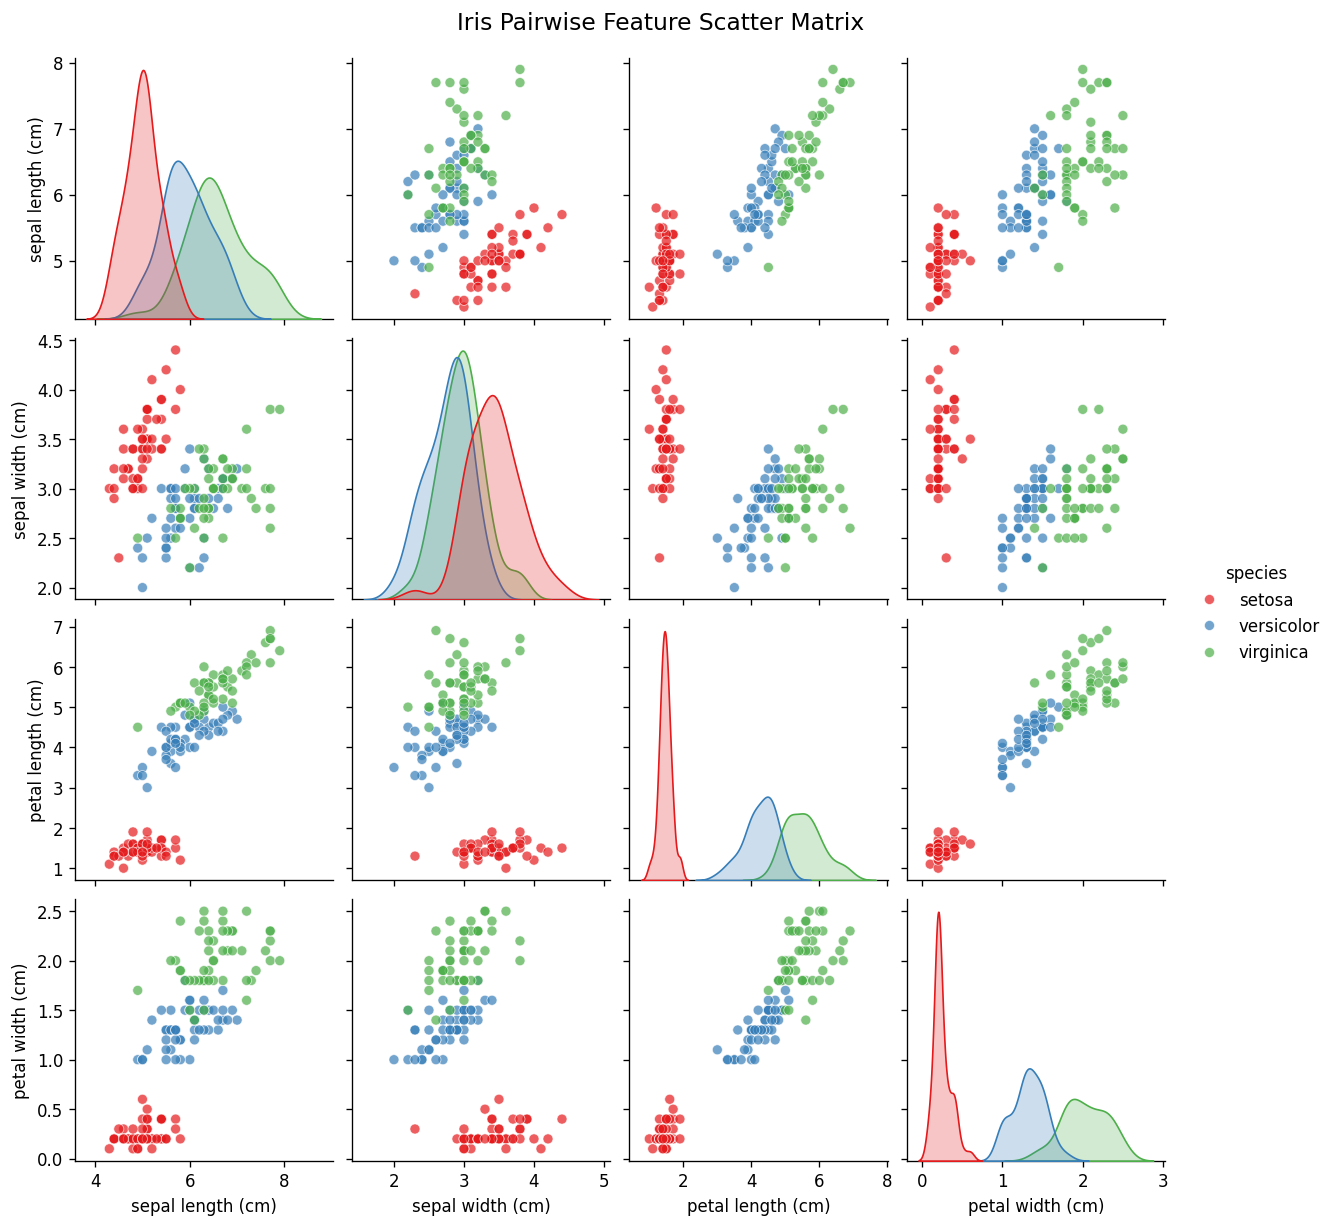

In [39]:
PlotPairPlot(df_iris, iris.feature_names)

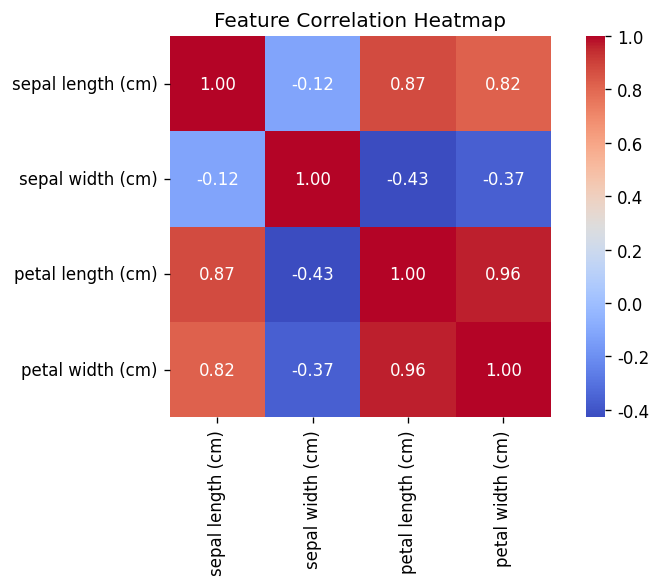

In [40]:
PlotCorrelationHeatmap(df_iris, iris.feature_names)

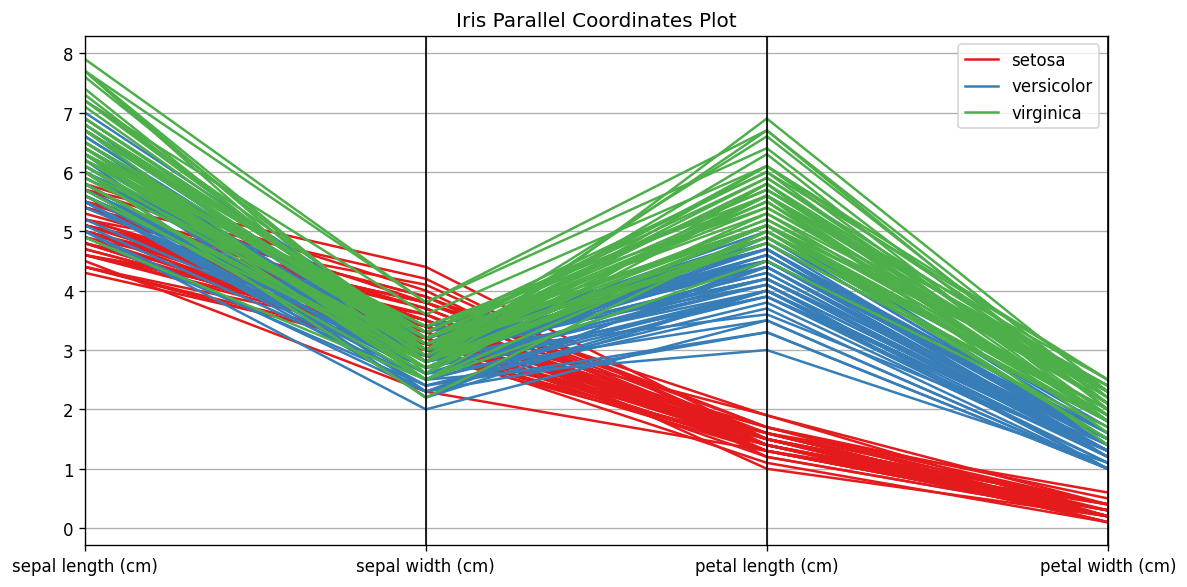

In [41]:
PlotParallelCoordinates(df_iris)

## **1.3 数据预处理**

In [42]:
X = iris.data
y = iris.target
X_train_scaled, X_test_scaled, y_train, y_test = SplitAndScale(X, y)

Training set: 120 samples
Test set:     30 samples

Standardization done.
Train mean: [-0. -0.  0.  0.]
Train std:  [1. 1. 1. 1.]


## **1.4 训练模型**

In [43]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc, 'f1': f1}
    print(f'{name}: Accuracy = {acc:.4f},  F1 (weighted) = {f1:.4f}\n')

Logistic Regression: Accuracy = 0.9333,  F1 (weighted) = 0.9333

Decision Tree: Accuracy = 0.9333,  F1 (weighted) = 0.9333

SVM (RBF): Accuracy = 0.9667,  F1 (weighted) = 0.9666



In [44]:
print('5-Fold Cross-Validation Results:')
print('-' * 50)
for name, info in results.items():
    scores = cross_val_score(info['model'], X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f'{name}: {scores.mean():.4f} +/- {scores.std():.4f}')

5-Fold Cross-Validation Results:
--------------------------------------------------
Logistic Regression: 0.9583 +/- 0.0264
Decision Tree: 0.9417 +/- 0.0204
SVM (RBF): 0.9667 +/- 0.0312


## **1.5 模型评估**

In [85]:
for name, info in results.items():
    print(f'{"=" * 64}\n{name} Classification Report\n{"-" * 64}')
    print(classification_report(y_test, info['y_pred'], target_names=iris.target_names))
    print("=" * 64, '\n')

Logistic Regression Classification Report
----------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Decision Tree Classification Report
----------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


SVM (RBF) Classification Rep

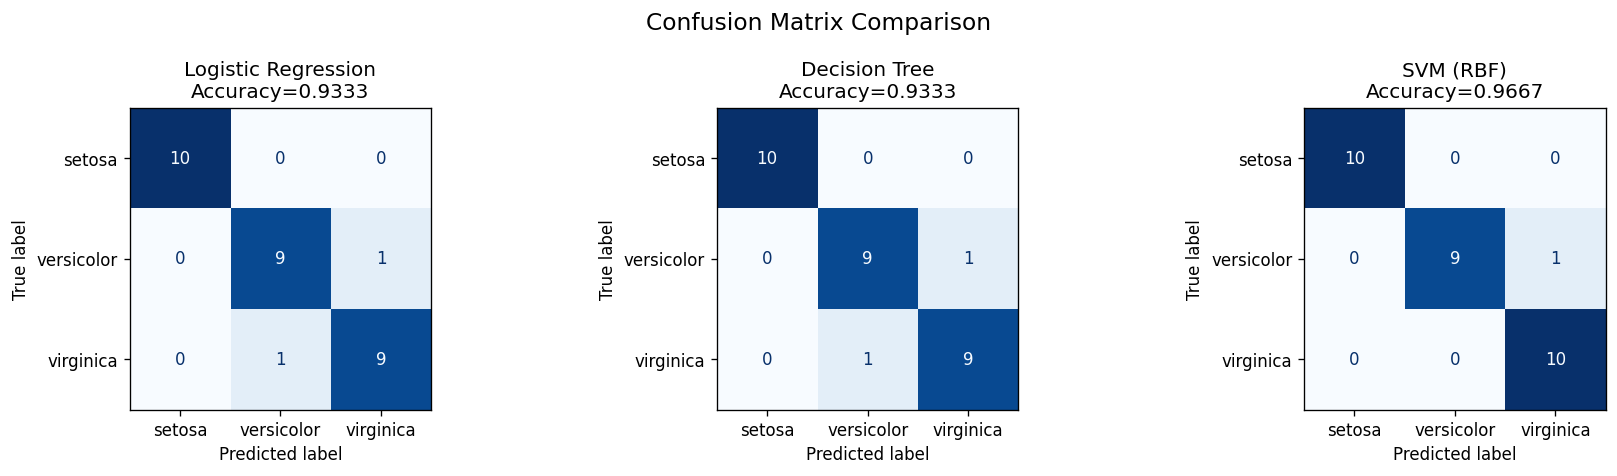

In [46]:
PlotConfusionMatrices(results, y_test, iris.target_names)

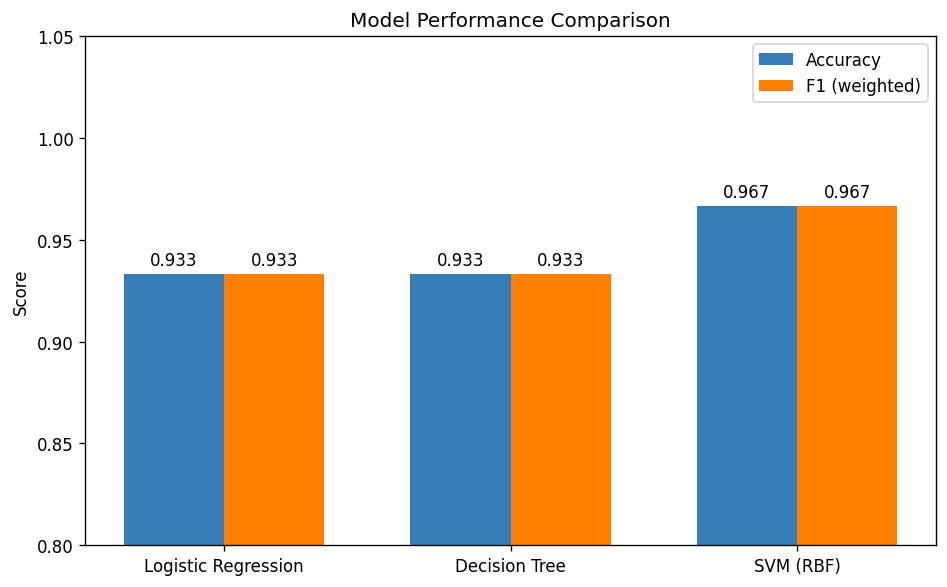

In [47]:
PlotPerformanceComparison(results)

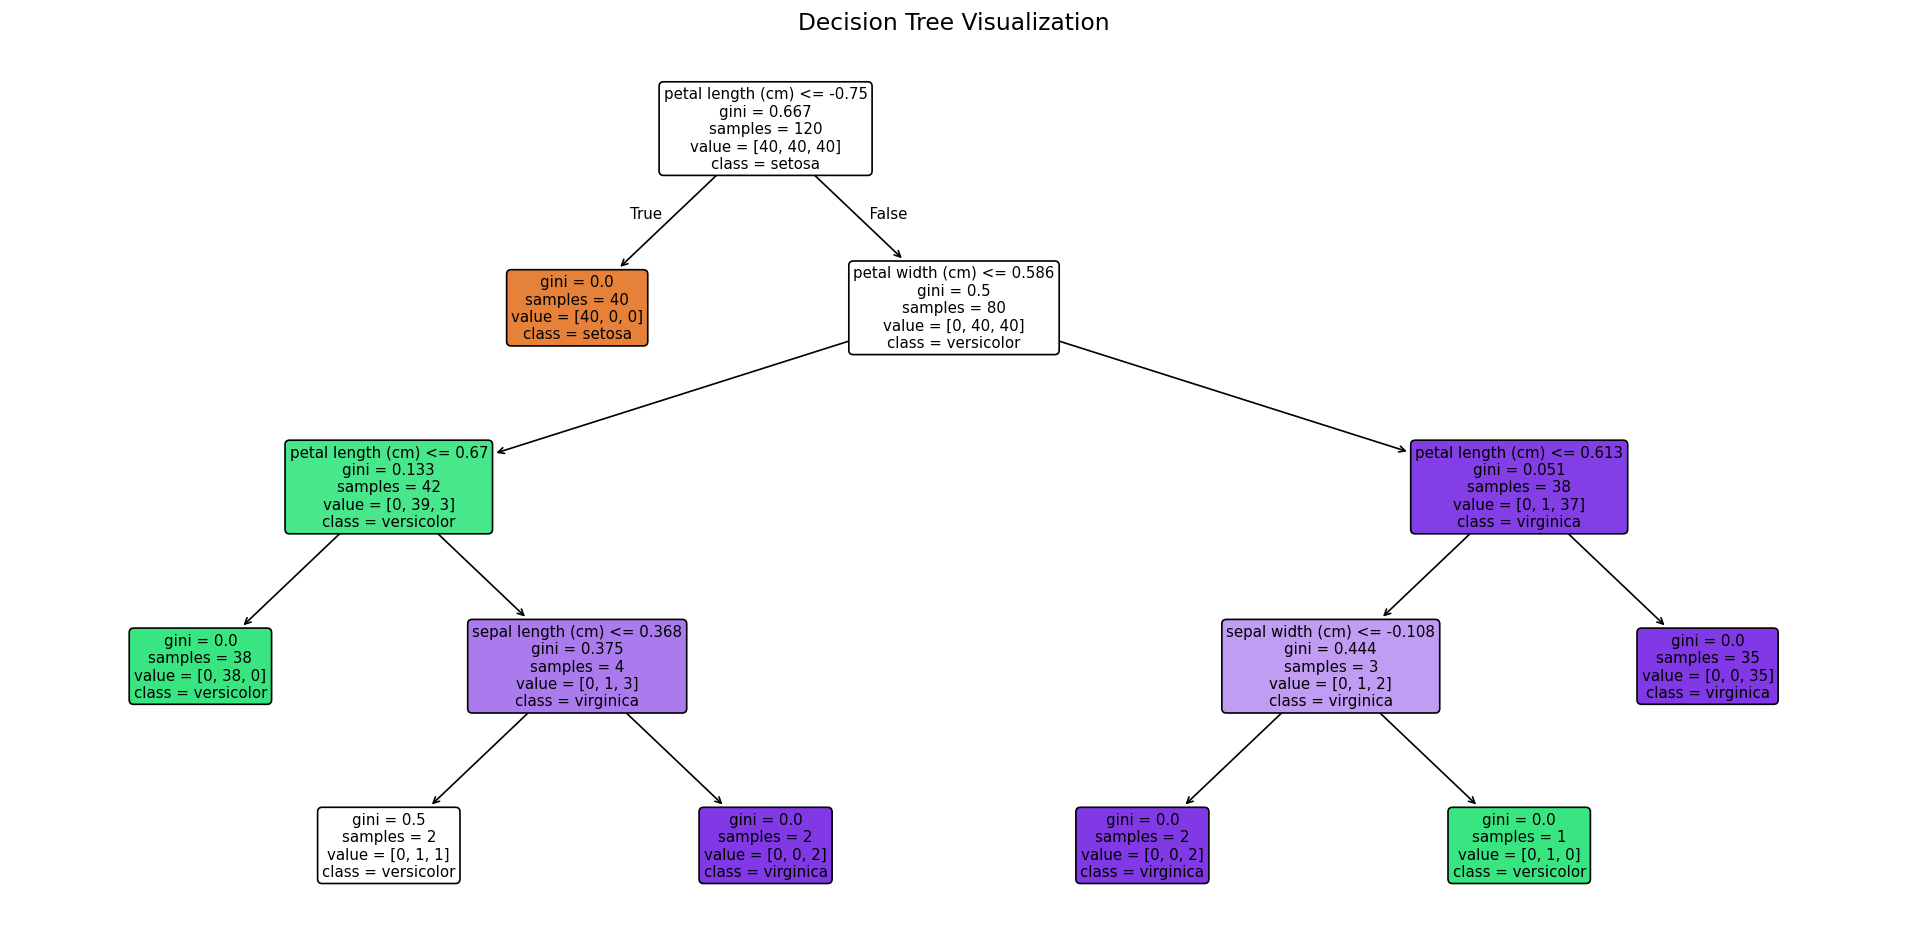

In [48]:
fig, ax = plt.subplots(figsize=(16, 8))
dt_model = results['Decision Tree']['model']
plot_tree(dt_model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True,
          rounded=True, ax=ax, fontsize=9)
ax.set_title('Decision Tree Visualization', fontsize=14)
plt.tight_layout()
plt.show()

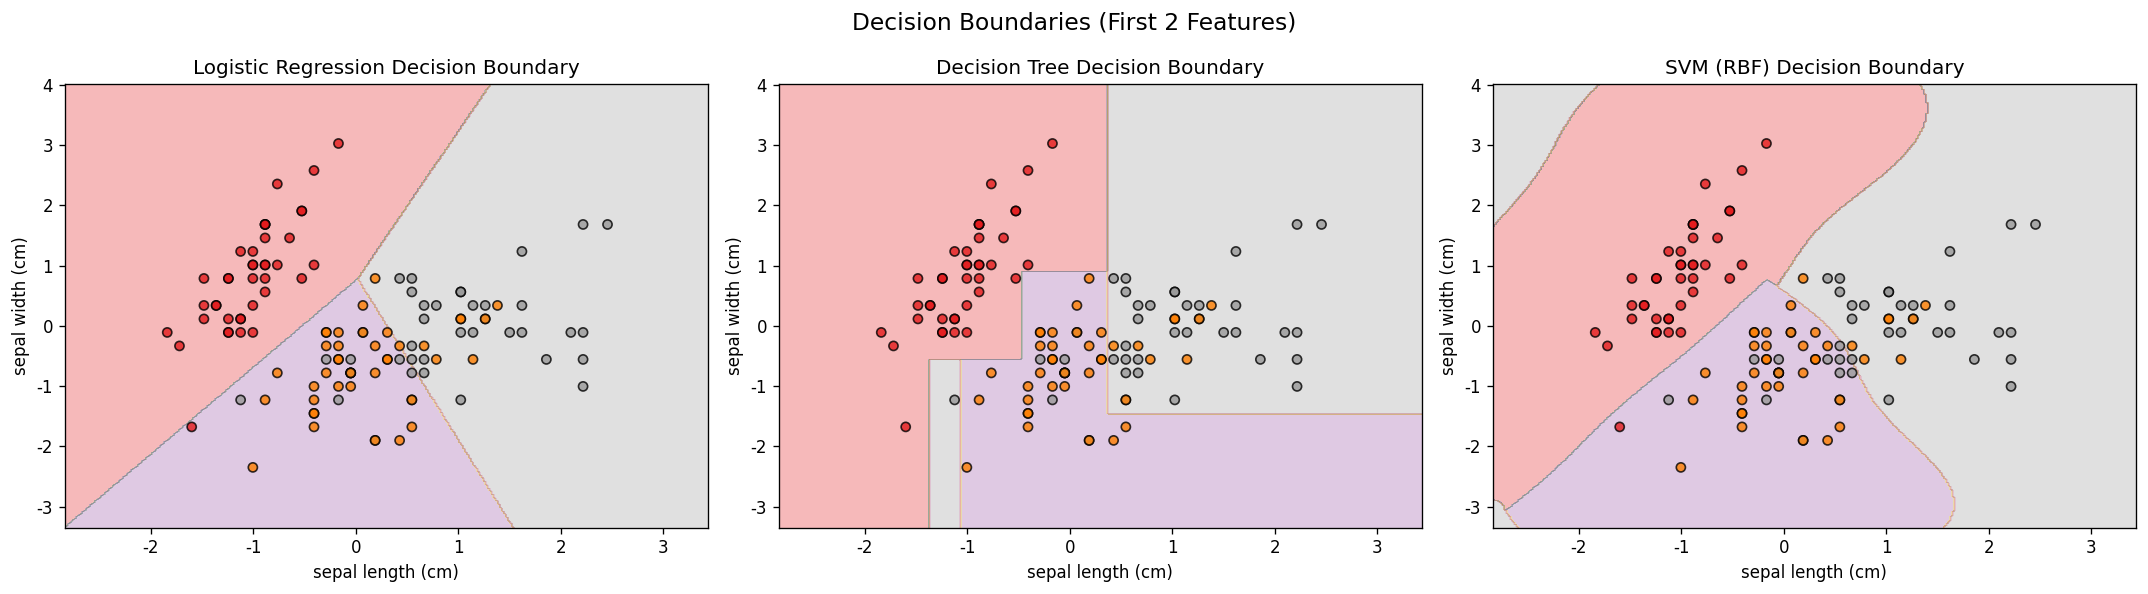

In [49]:
X2 = X_train_scaled[:, :2]
models_2d = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(models_2d.items()):
    model.fit(X2, y_train)
    PlotDecisionBoundary(model, X2, y_train,
                         [iris.feature_names[0], iris.feature_names[1]],
                         f'{name} Decision Boundary', axes[idx])
fig.suptitle('Decision Boundaries (First 2 Features)', fontsize=14)
plt.tight_layout()
plt.show()

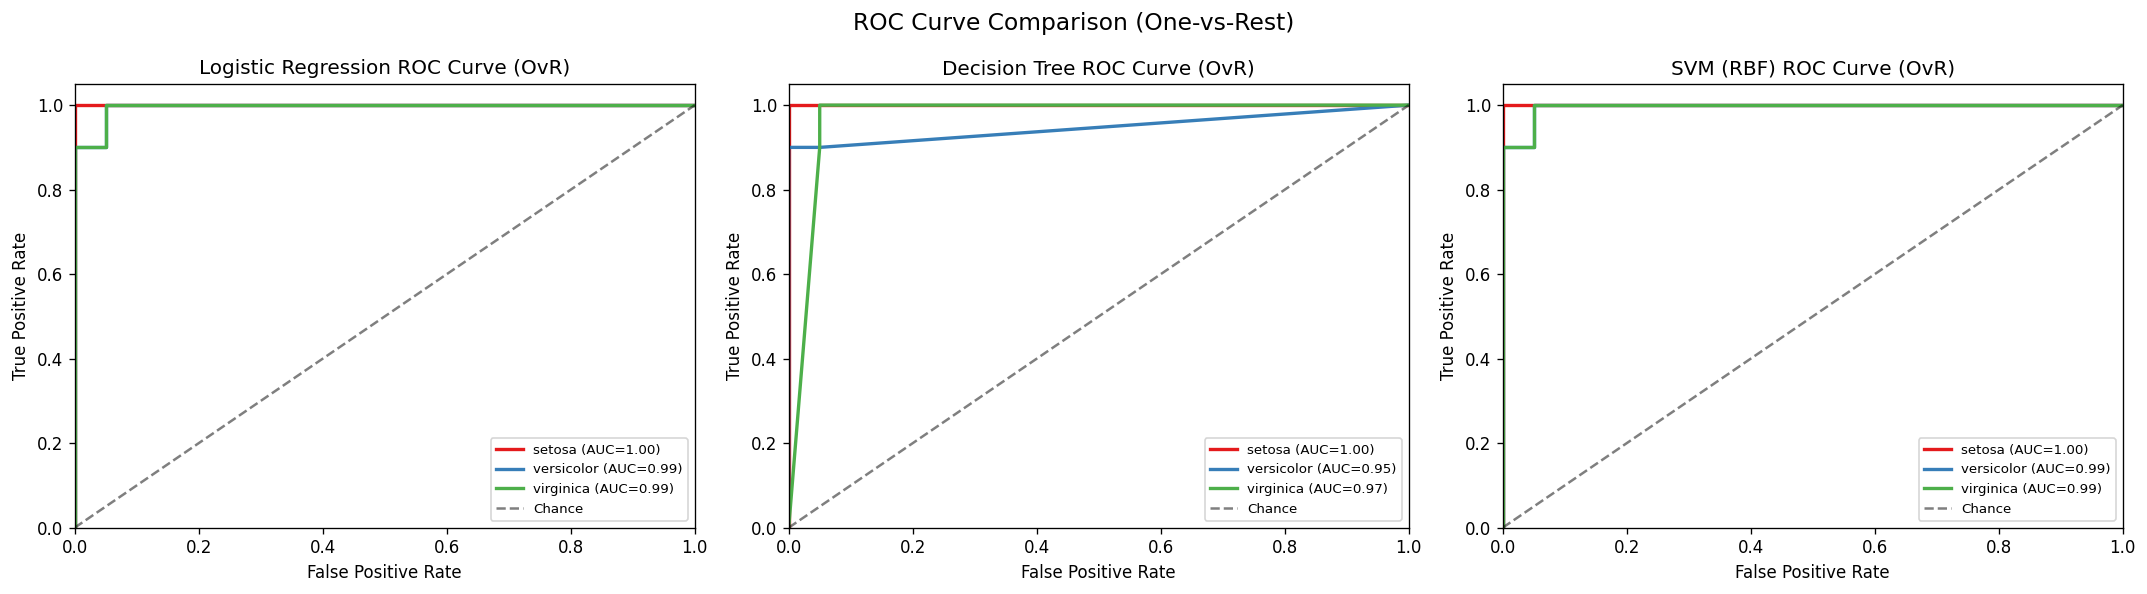

In [50]:
PlotROCCurves(results, X_test_scaled, y_test, iris.target_names)

## **1.6 超参数影响分析**

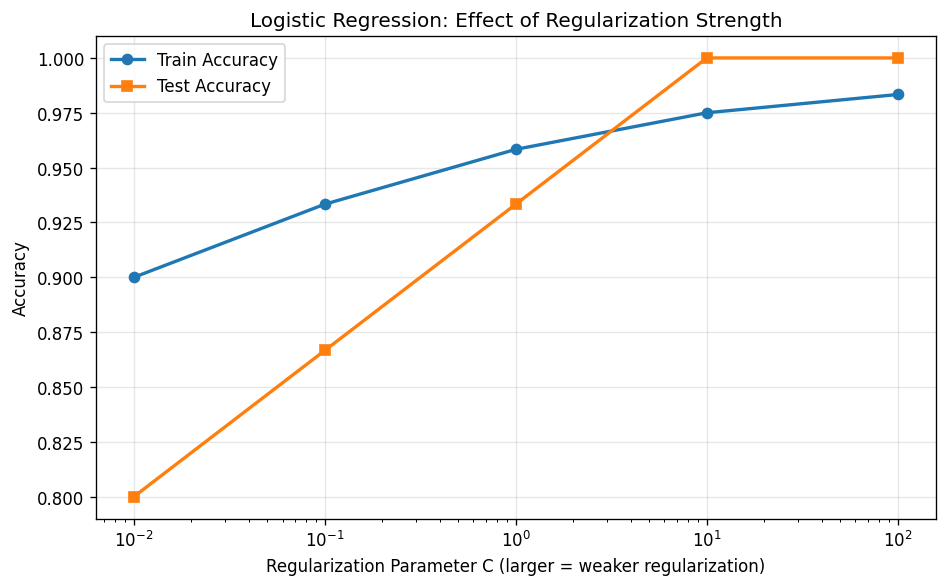

In [51]:
C_values = [0.01, 0.1, 1, 10, 100]
train_accs, test_accs = [], []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=200, random_state=42)
    lr.fit(X_train_scaled, y_train)
    train_accs.append(lr.score(X_train_scaled, y_train))
    test_accs.append(lr.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_values, train_accs, 'o-', label='Train Accuracy', linewidth=2)
ax.plot(C_values, test_accs, 's-', label='Test Accuracy', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Regularization Parameter C (larger = weaker regularization)')
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression: Effect of Regularization Strength')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

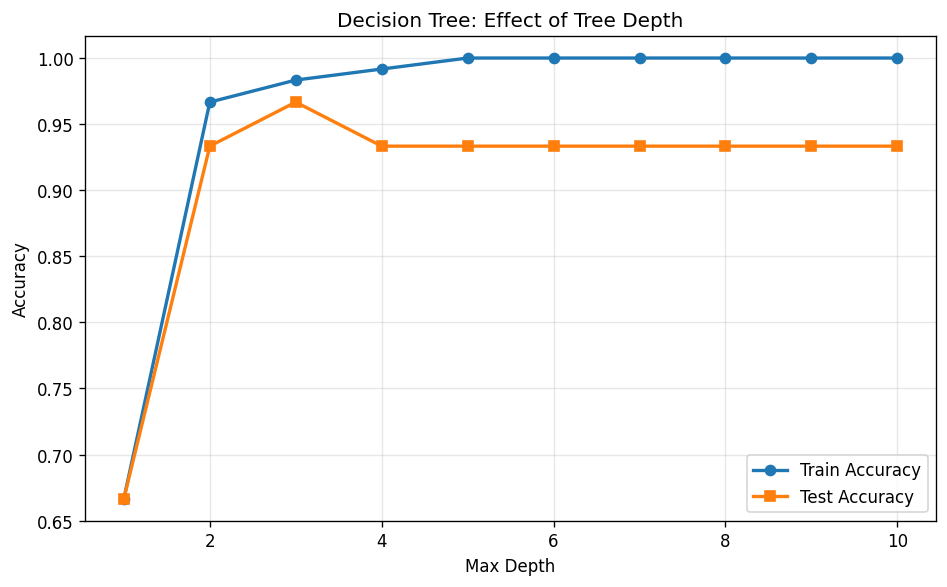

In [52]:
depths = range(1, 11)
train_accs_dt, test_accs_dt = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs_dt.append(dt.score(X_train_scaled, y_train))
    test_accs_dt.append(dt.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_accs_dt, 'o-', label='Train Accuracy', linewidth=2)
ax.plot(depths, test_accs_dt, 's-', label='Test Accuracy', linewidth=2)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: Effect of Tree Depth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

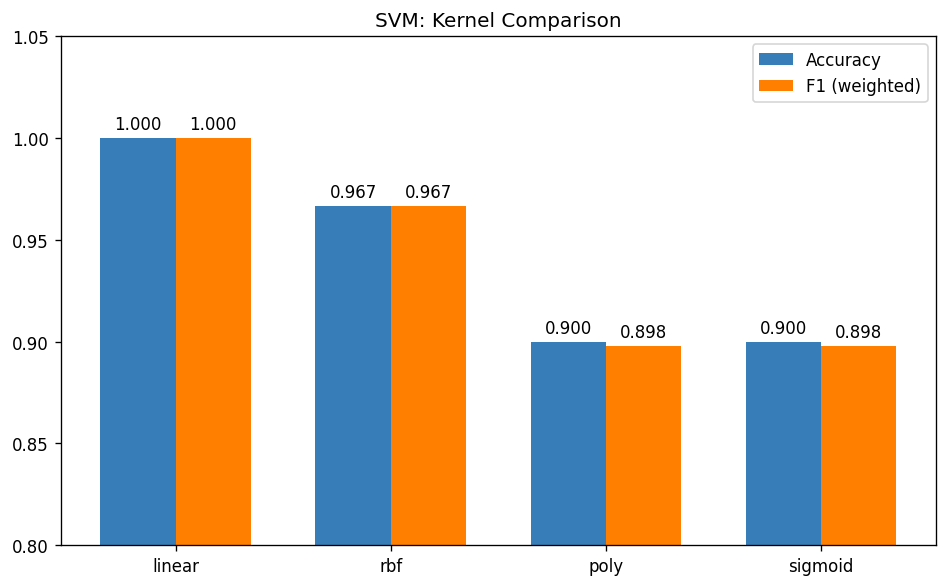

In [53]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    svm_results[kernel] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(kernels))
width = 0.35
bars1 = ax.bar(x - width/2, [svm_results[k]['accuracy'] for k in kernels],
               width, label='Accuracy', color='#377eb8')
bars2 = ax.bar(x + width/2, [svm_results[k]['f1'] for k in kernels],
               width, label='F1 (weighted)', color='#ff7f00')
ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.set_ylim(0.8, 1.05)
ax.set_title('SVM: Kernel Comparison')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

# **2. 无监督学习——客户细分**

## **2.1 加载数据**

In [54]:
df_mall = LoadMallCustomers(path=UNSUPERVISED_DATASET)

Shape: (200, 5)

Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [55]:
df_mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## **2.2 数据可视化**

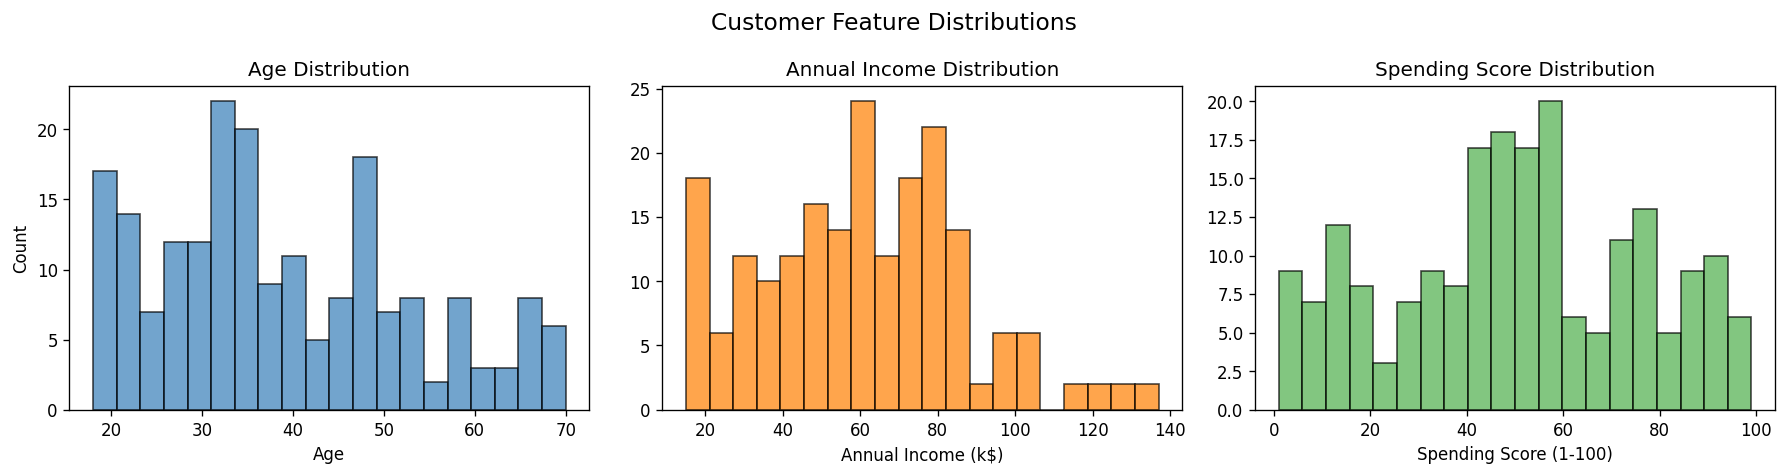

In [56]:
PlotDistributions(df_mall)

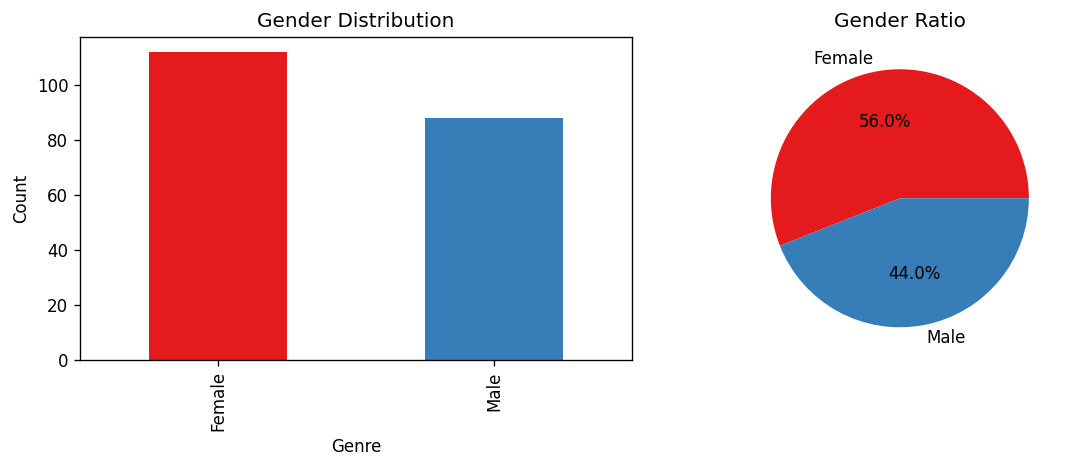

In [57]:
PlotGenderDistribution(df_mall)

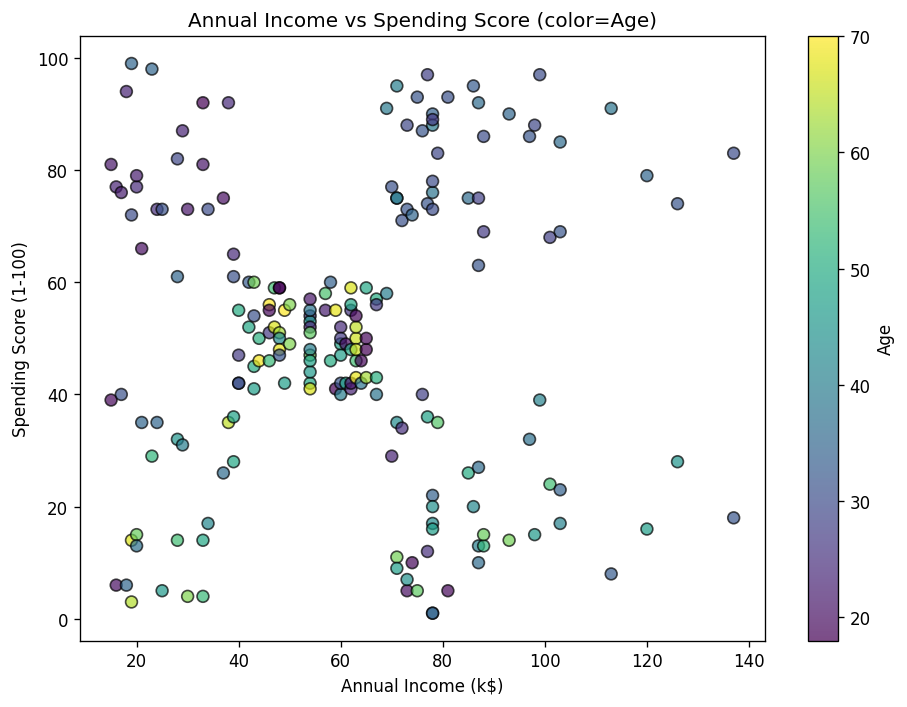

In [58]:
PlotIncomeVsSpending(df_mall)

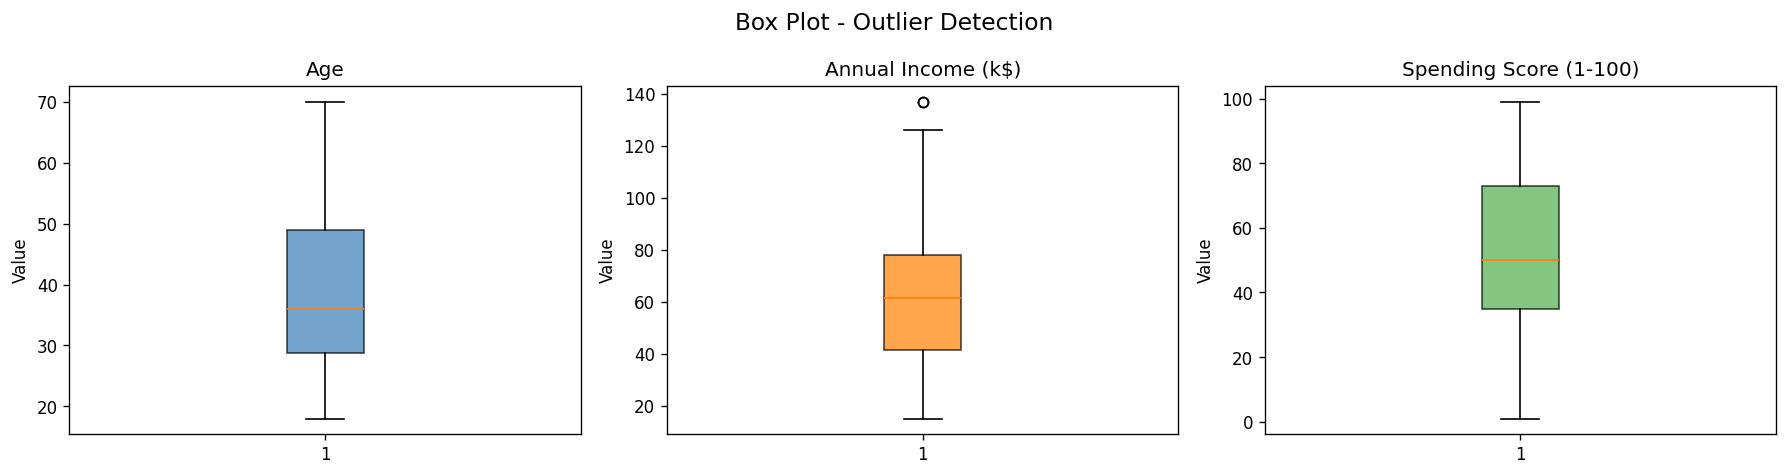

In [59]:
PlotMallBox(df_mall)

## **2.3 数据预处理**

In [60]:
X_mall_scaled, scaler_mall, features_for_clustering = PreprocessMall(df_mall)

Clustering features: ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Data shape: (200, 4)
Standardized mean: [ 0. -0. -0. -0.]
Standardized std:  [1. 1. 1. 1.]


## **2.4 降维**

In [61]:
X_pca, pca = ReducePCA(X_mall_scaled)

PCA explained variance ratio: [0.3369 0.2623]
Cumulative explained variance: 0.5992


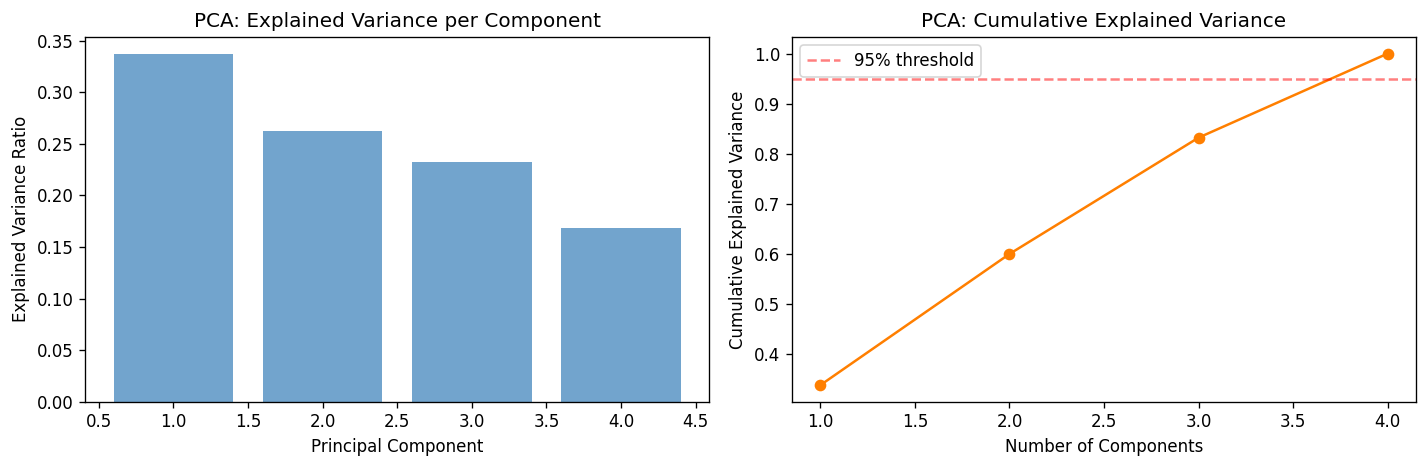

In [62]:
PlotPCAVariance(X_mall_scaled)

In [63]:
X_tsne = ReduceTSNE(X_mall_scaled)

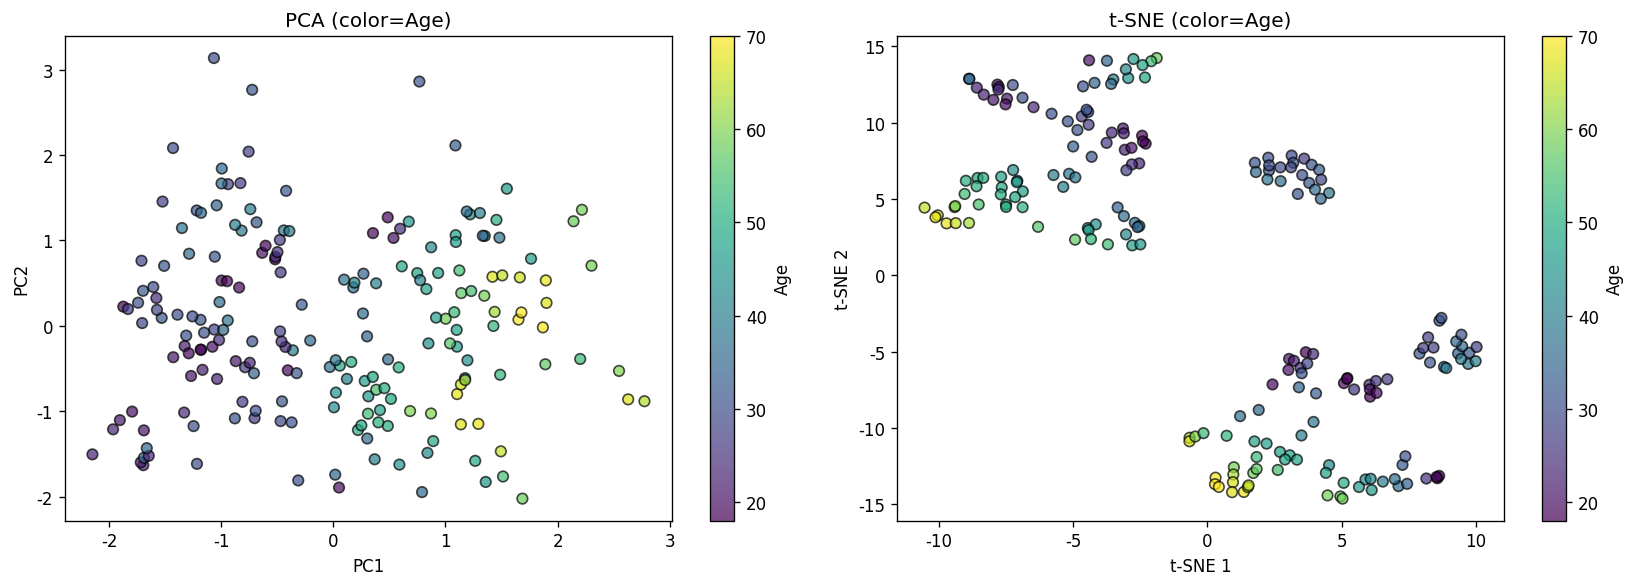

In [64]:
PlotDimComparison(X_pca, X_tsne, df_mall)

## **2.5 聚类分析**

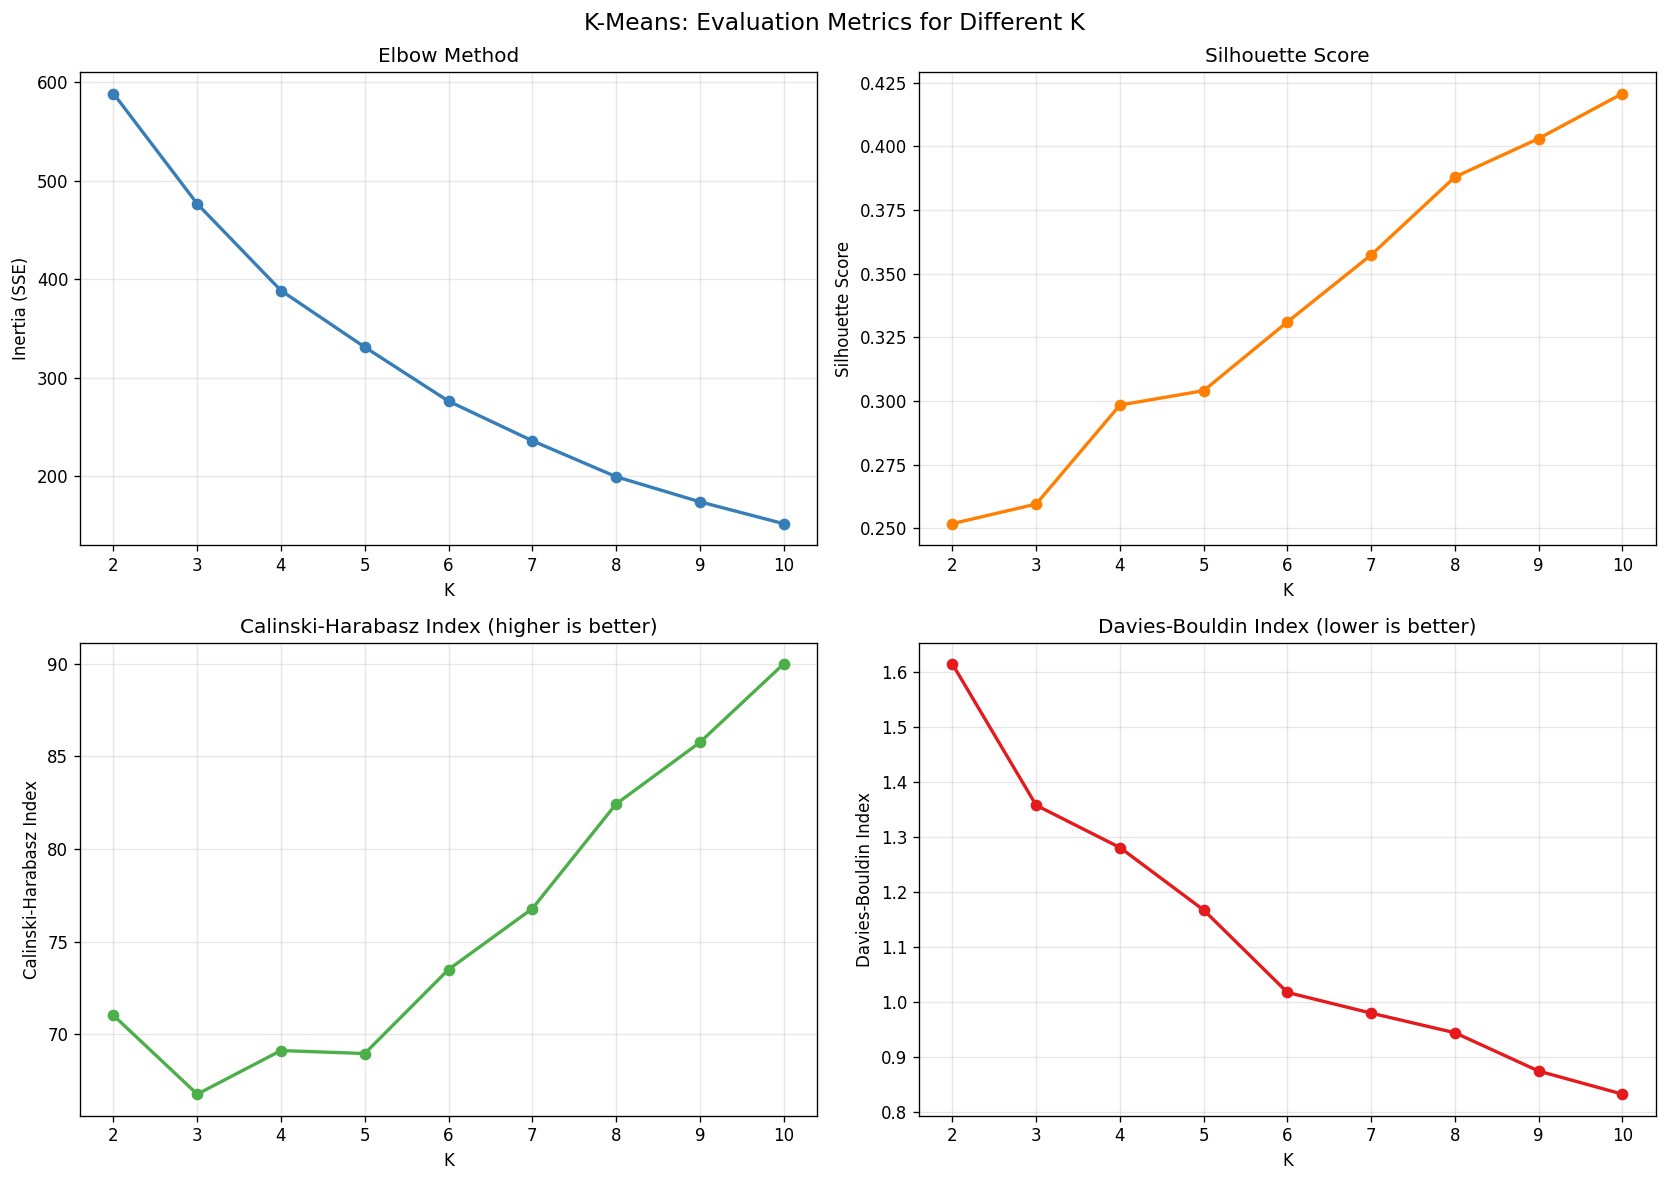

Best K by silhouette score = 10 (Score = 0.4208)


In [65]:
best_k, _ = EvaluateKMeans(X_mall_scaled)

In [66]:
best_k = 5
print(f'Using K = {best_k}')

Using K = 5


In [67]:
clustering_results = RunClustering(X_mall_scaled, best_k)


KMeans: 5 clusters, 0 noise points
  Label distribution: {0: 39, 1: 29, 2: 43, 3: 54, 4: 35}
  Silhouette Score: 0.3041
  Calinski-Harabasz: 68.96
  Davies-Bouldin: 1.1672

Agglomerative: 5 clusters, 0 noise points
  Label distribution: {0: 61, 1: 39, 2: 33, 3: 38, 4: 29}
  Silhouette Score: 0.2870
  Calinski-Harabasz: 64.47
  Davies-Bouldin: 1.2198

DBSCAN: 2 clusters, 1 noise points
  Label distribution: {0: 87, 1: 112}
  Silhouette Score: 0.2790
  Calinski-Harabasz: 67.32
  Davies-Bouldin: 1.6030


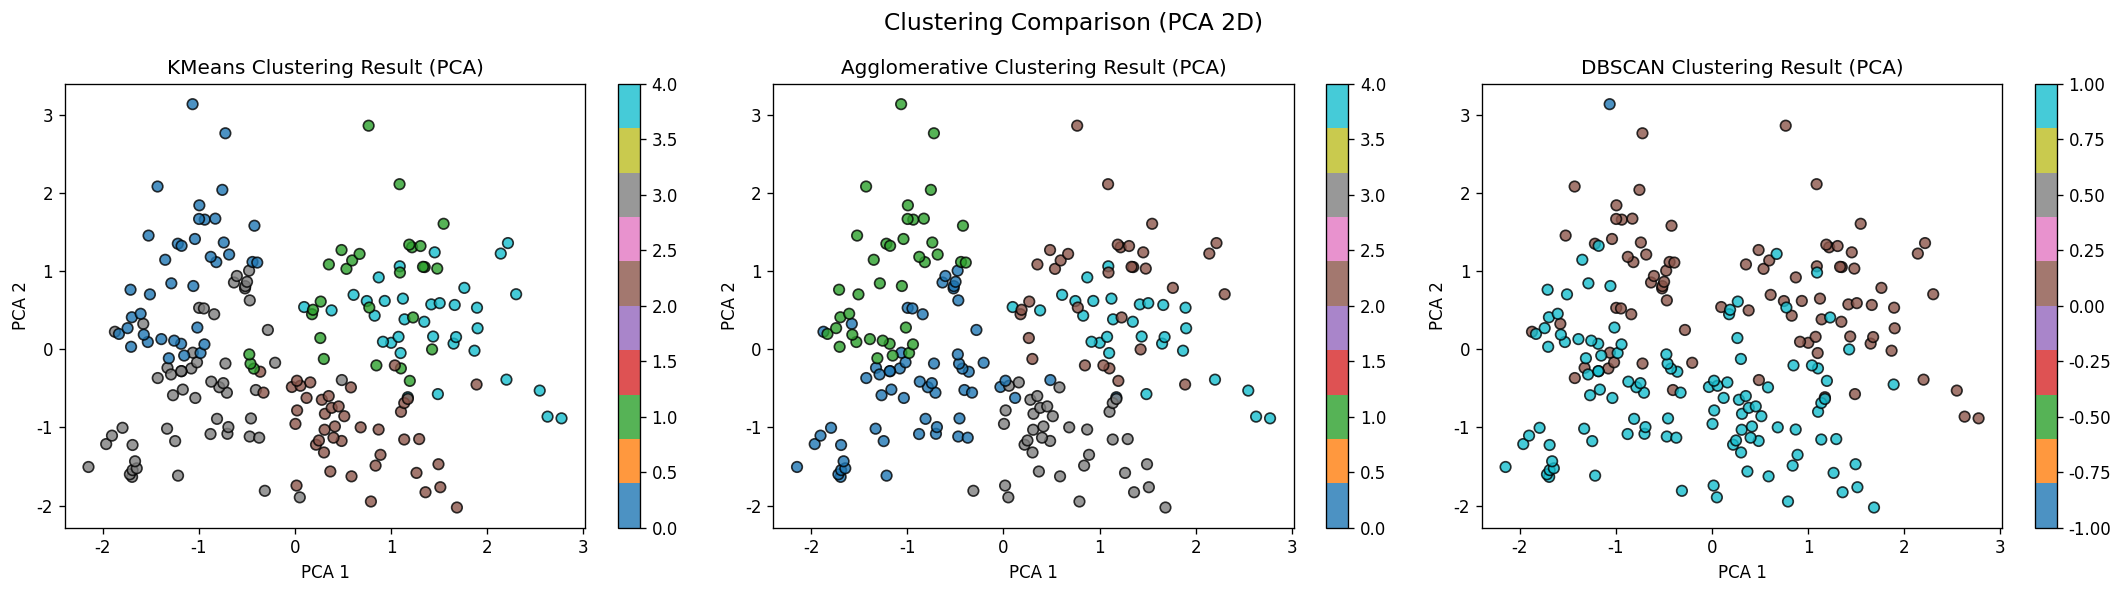

In [68]:
PlotClusteringComparison(clustering_results, X_pca, 'PCA')

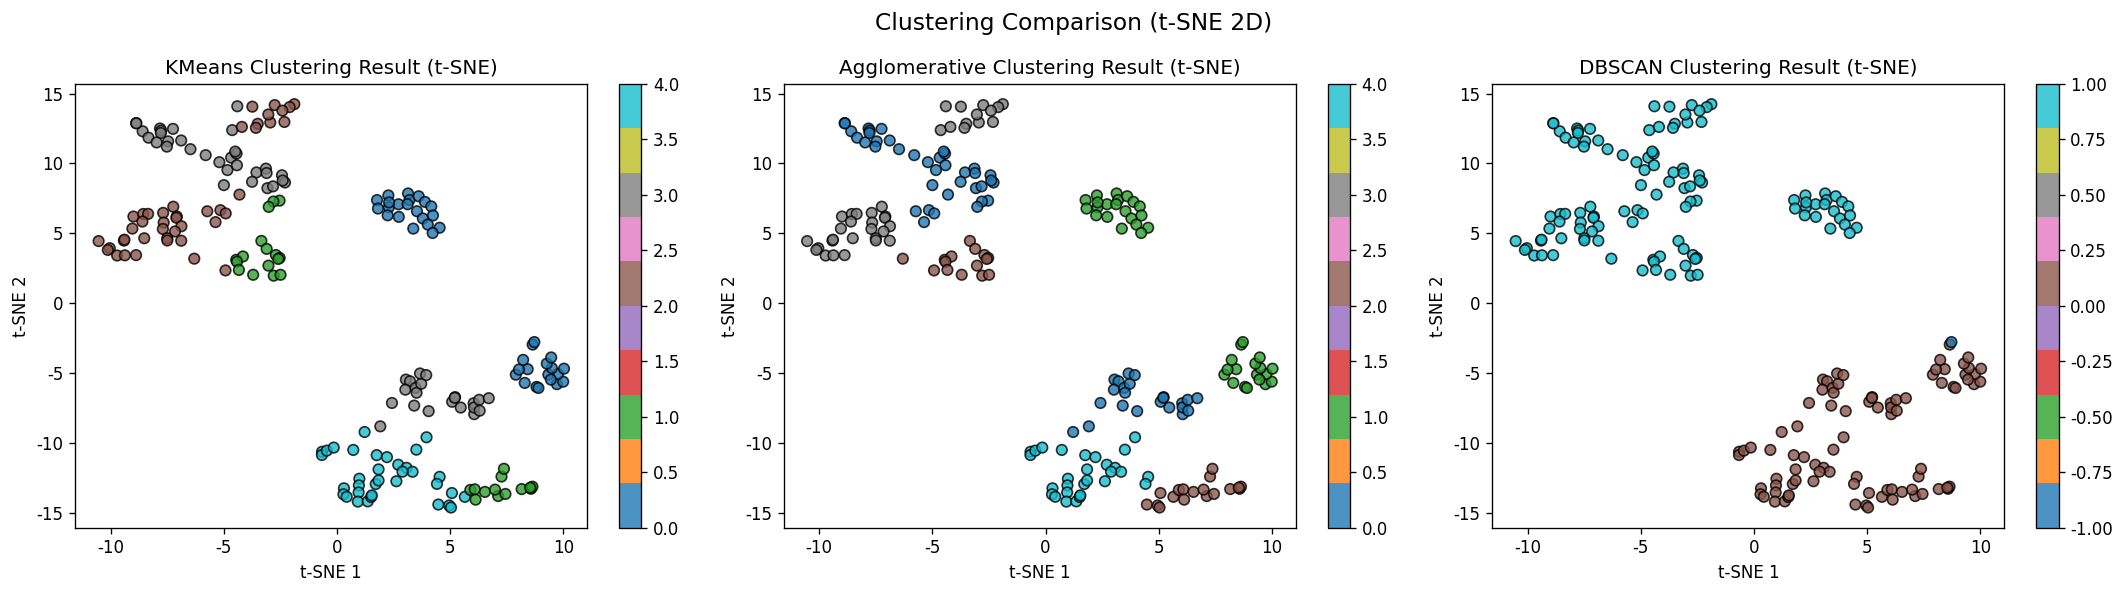

In [69]:
PlotClusteringComparison(clustering_results, X_tsne, 't-SNE')

In [70]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_mall_scaled)
df_mall['KMeans_Cluster'] = kmeans_final.labels_

In [71]:
PlotClusterCenters(kmeans_final, scaler_mall, features_for_clustering, best_k)

K-Means Cluster Centers (original scale):


,Gender_encoded,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.46,32.69,86.54,82.13
1,0.45,36.48,89.52,18.00
2,-0.00,49.81,49.23,40.07
3,0.41,24.91,39.72,61.20
4,1.00,55.71,53.69,36.77


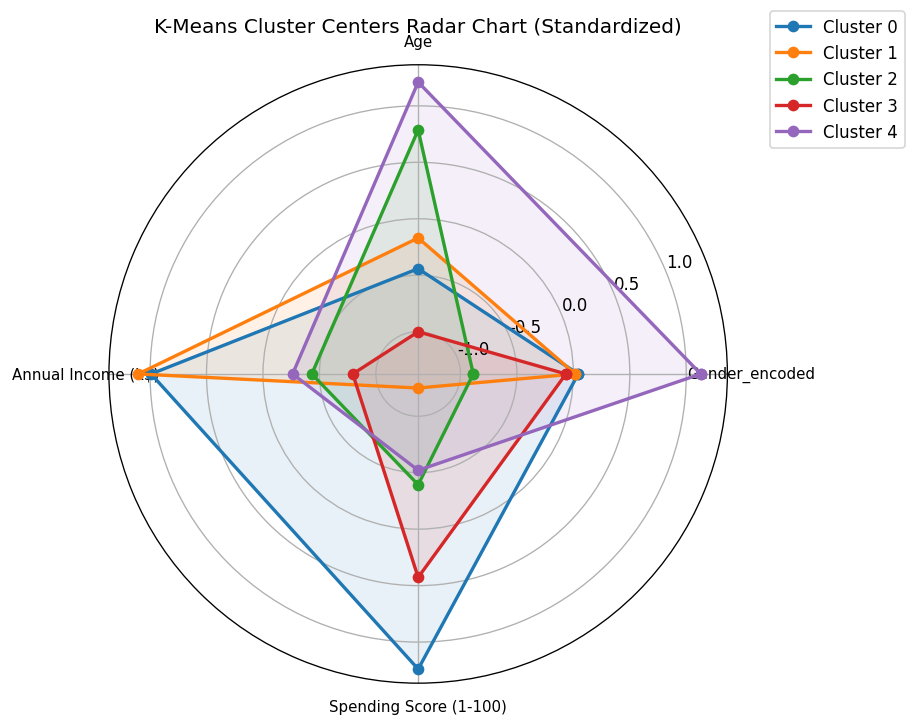

In [72]:
PlotRadarChart(kmeans_final, features_for_clustering, best_k)

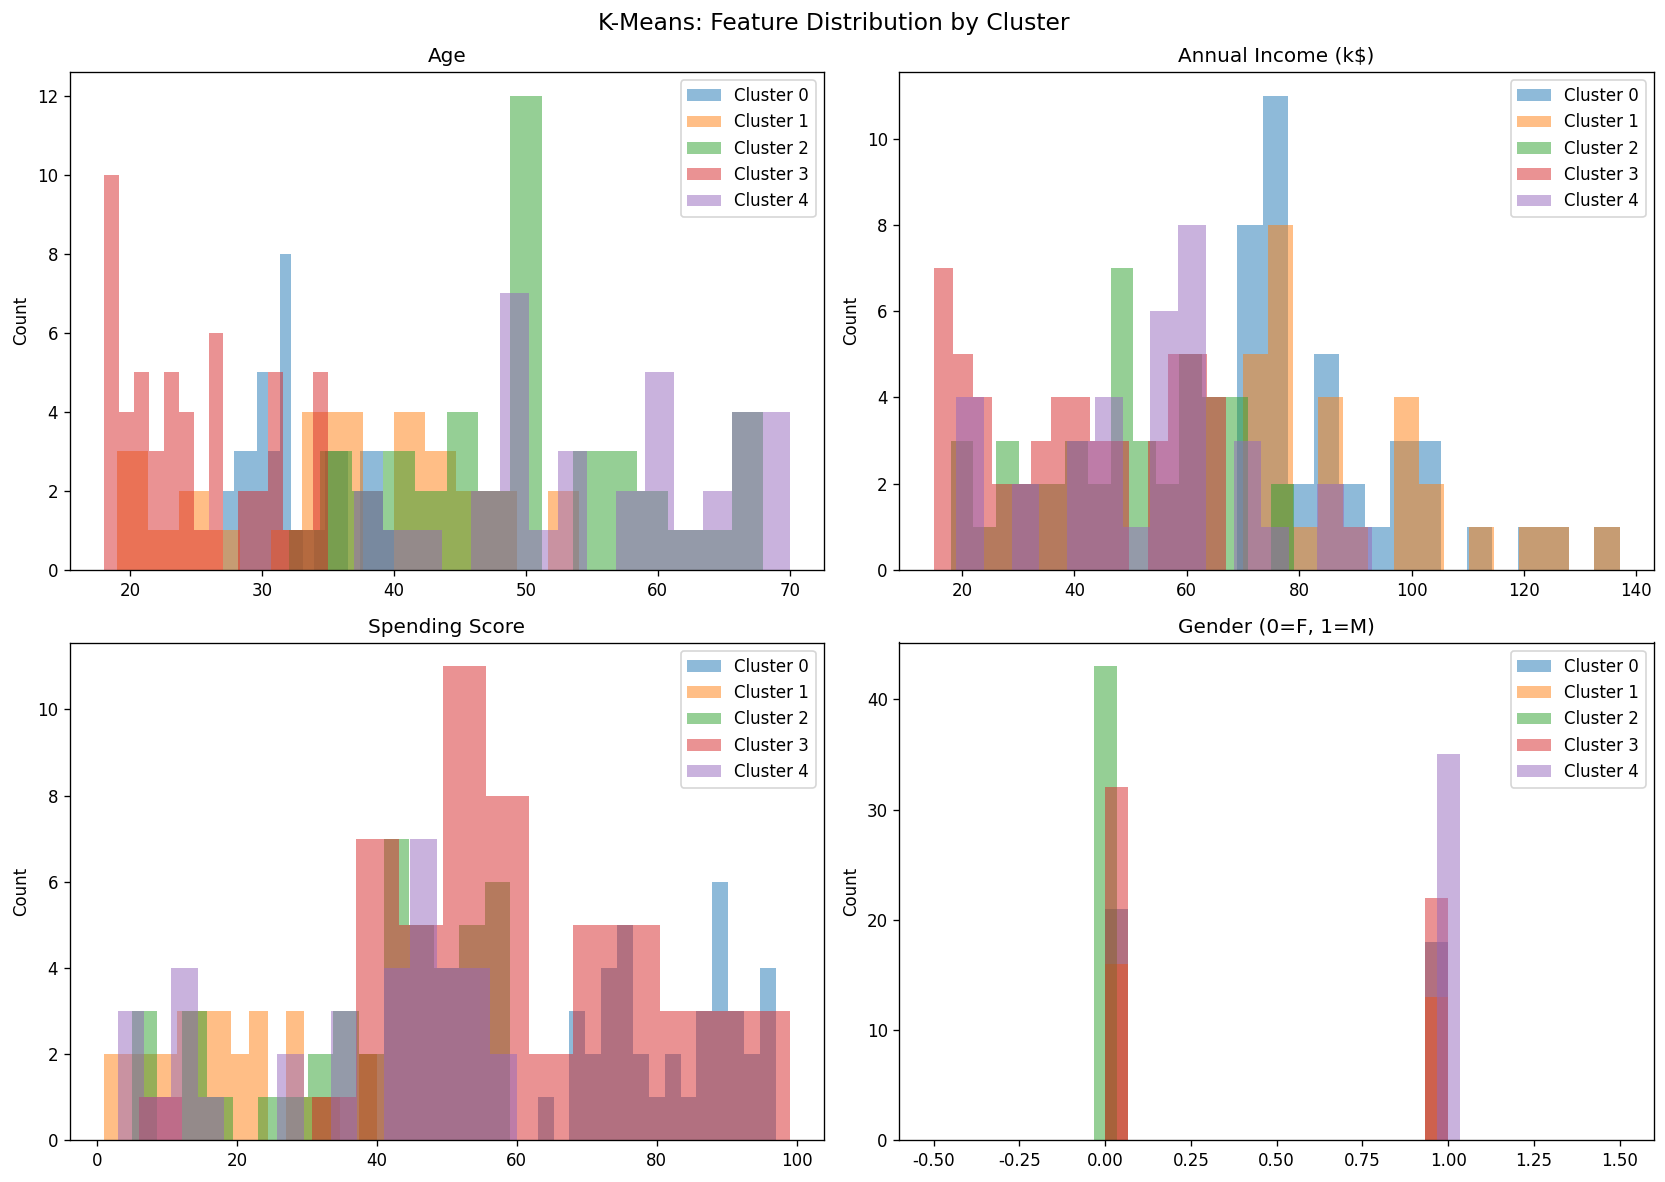

In [73]:
PlotFeatureDistributionByCluster(df_mall, best_k,
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded'],
    ['Age', 'Annual Income (k$)', 'Spending Score', 'Gender (0=F, 1=M)'])

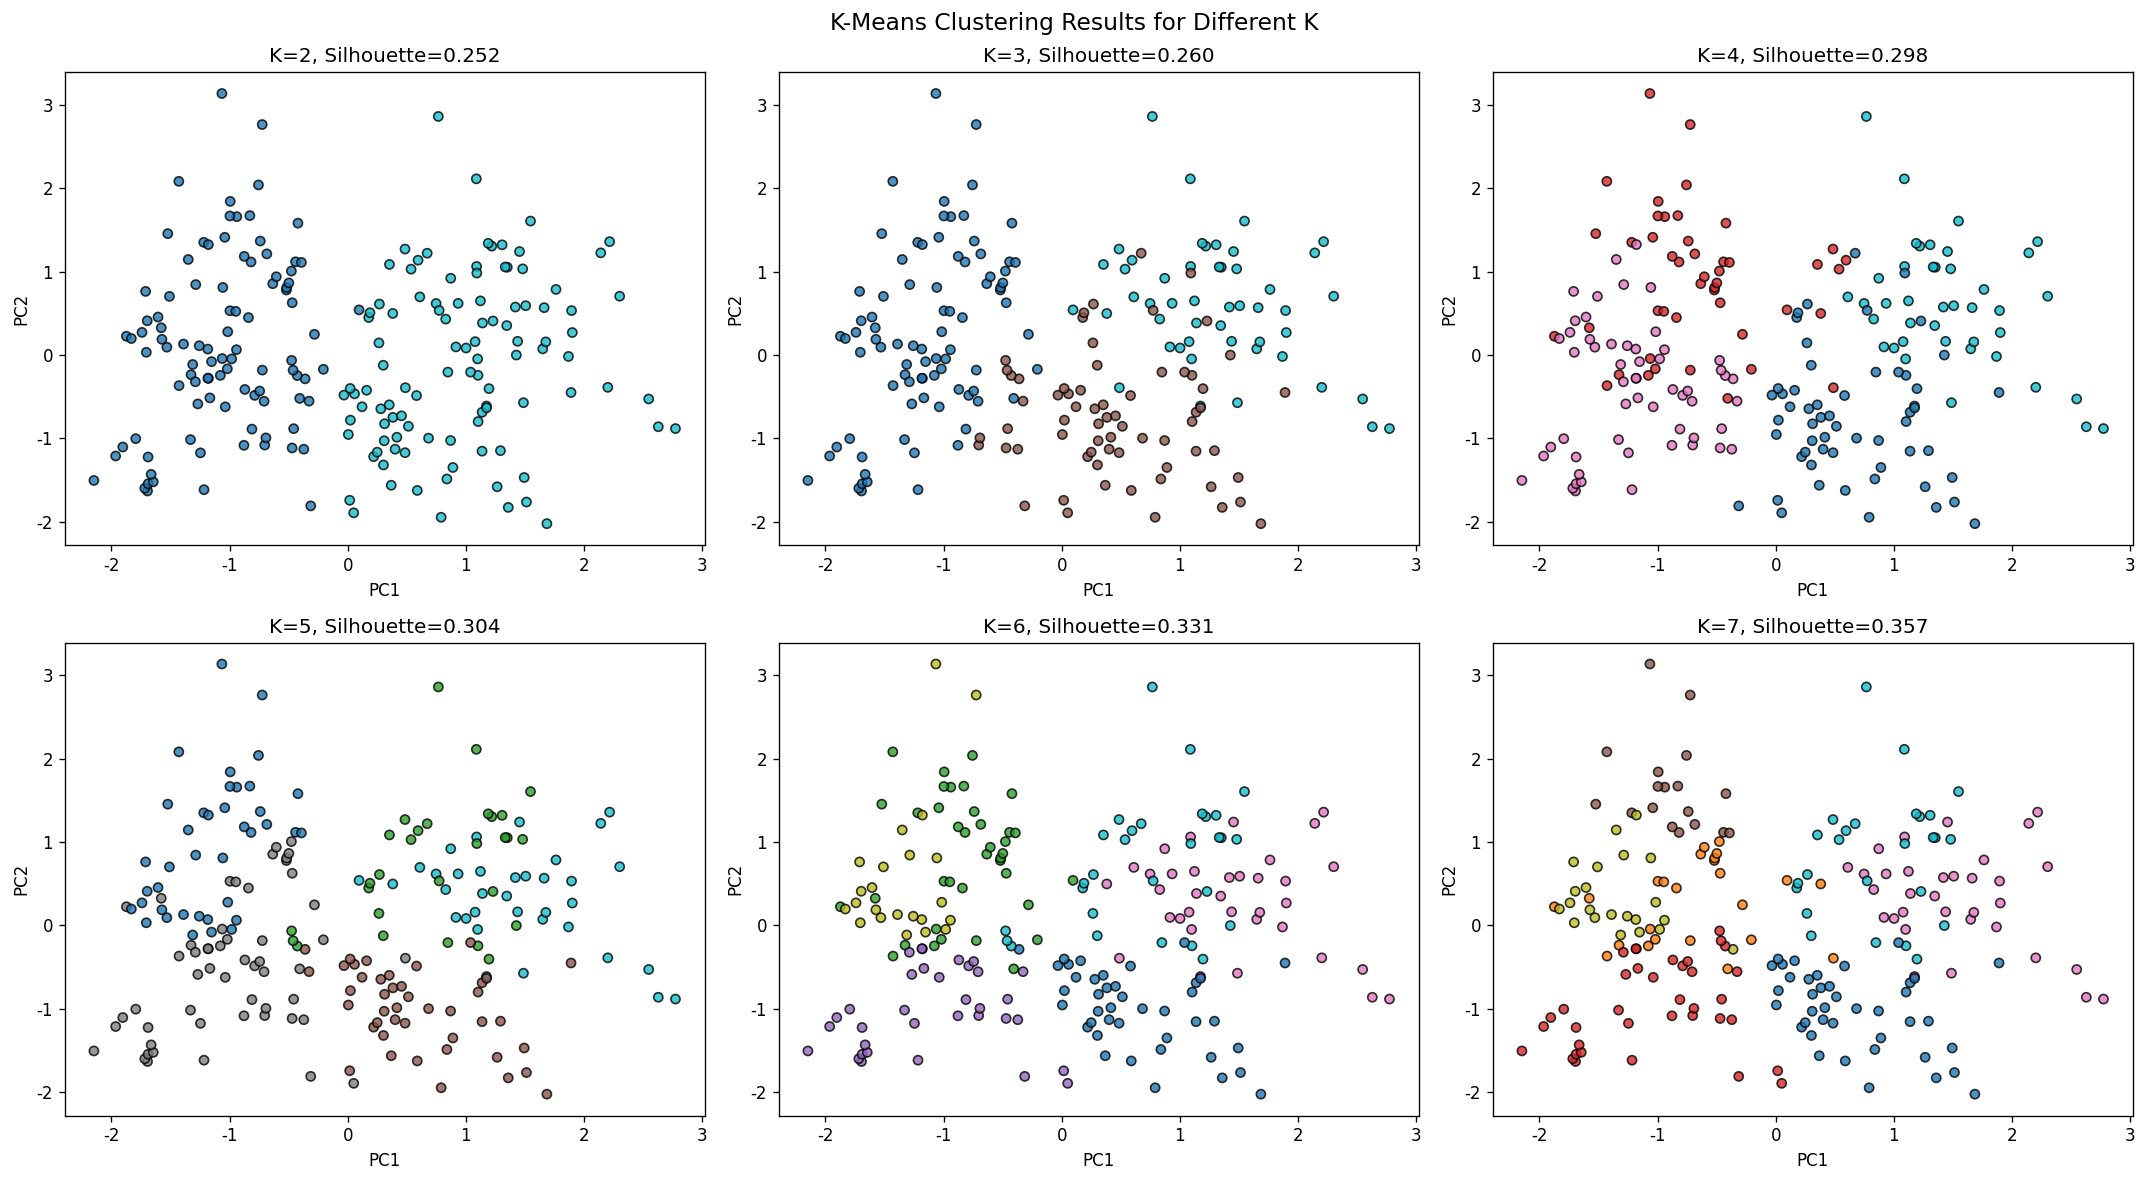

In [74]:
PlotKComparison(X_mall_scaled, X_pca)